# Subtyping EM with Grid Search and K-Fold Cross-Validation

This notebook performs grid search over hyperparameters using K-fold cross-validation (not group k-fold).


In [43]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import random
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import confusion_matrix, adjusted_rand_score
from EMDPM.model_generator import generate_logistic_model, get_adjacency_matrix, create_patient_list
from EMDPM.synthetic_data_generator import generate_synthetic_data
from EMDPM.visualization import * 
from EMDPM.utils import *
from EMDPM.subtyping_em_transformer import SubtypingEM
from EMDPM.posthoc_burnin_subtype_initialization import initialize_subtypes_with_burnin

np.set_printoptions(precision=4)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
# data params
n_biomarkers = 3
t_max = 12
t_span = np.linspace(0, t_max, 8000)
noise_level = 0.0
n_patients = 150 # was 200
n_patient_obs = 3
n_subtypes = 3 #3,4,5
rng = np.random.RandomState(75)


For subtype data generation: different sets of trajectories are generated for each subtype. 
- K is held constant for each subtype
- f and scalar_K are different for each subtype

- removed variablity in time point, now they are in intervals of integer years to mirror ppmi data.
- only one copy of beta now generated instead of three identical copies.


SUBTYPE 0:
f: [0.  0.  0.3]
a = 4.676436127196727, b = 6.421955999238555


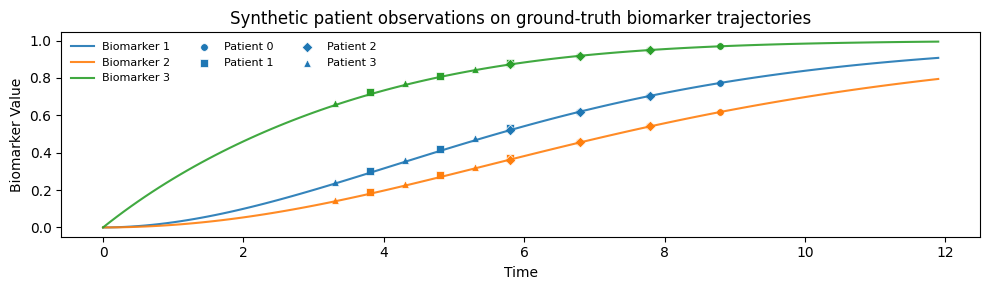

4.652100779497804
SUBTYPE 1:
f: [0.3 0.  0. ]
a = 1.1927249100009507, b = 6.8096301386771785


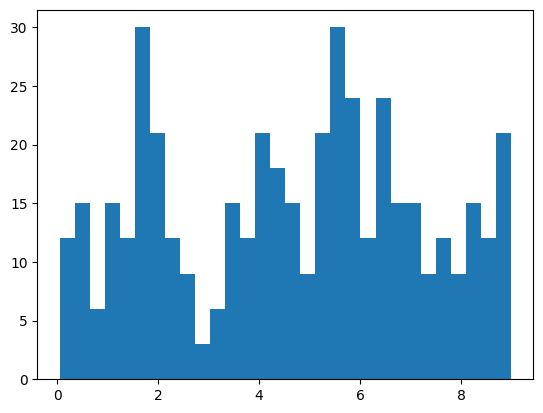

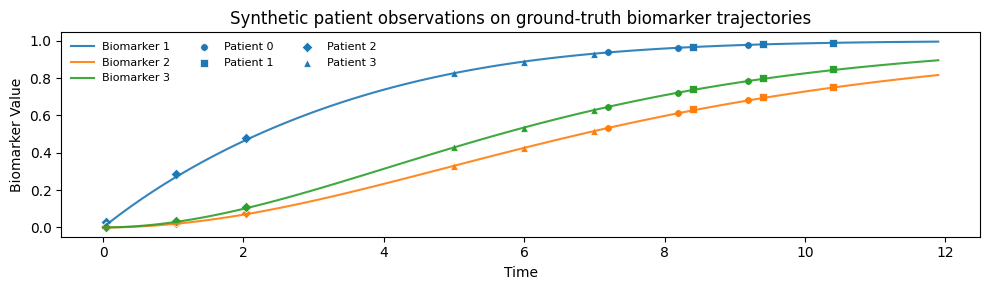

4.369259360008201
SUBTYPE 2:
f: [0.  0.3 0. ]
a = 3.0026725053615246, b = 4.680674259481151


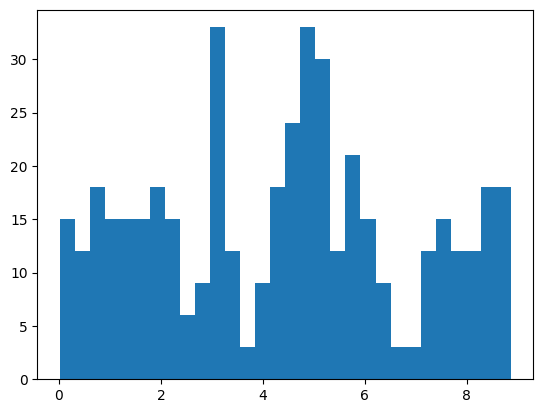

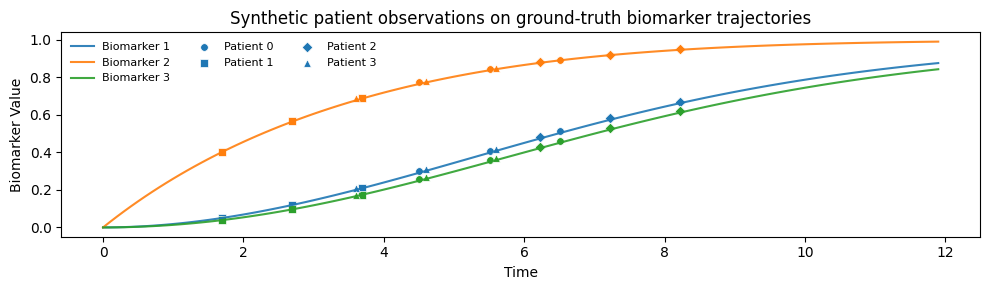

4.495167591409237


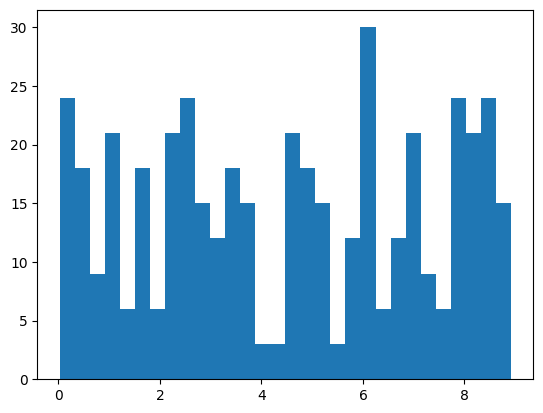

In [45]:
K = get_adjacency_matrix("random_offdiag", n_biomarkers, np.random.RandomState(75))

scalar_K_list = [0.2, 0.2, 0.2]
f_list = []
for _ in range(n_subtypes):
    f_list.append(rng.gamma(shape=2, scale=0.005, size=n_biomarkers))

f_list = [np.array([0.0, 0.0, 0.3]), np.array([0.3, 0.0, 0.0]), np.array([0.0, 0.3, 0.0])]

X = []
y = []

for subtype in range(n_subtypes):
    print(f"SUBTYPE {subtype}:")
    t, x_true, K, x0, f, scalar_K  = generate_logistic_model(n_biomarkers = n_biomarkers,
                                                             scalar_K = scalar_K_list[subtype],
                                                             t_max = t_max,
                                                             K = K,
                                                             f = f_list[subtype])

    print(f"f: {f}")
    
    df, cog_a, cog_b = generate_synthetic_data(
        n_biomarkers = n_biomarkers,
        t_max = t_max, 
        noise_level = noise_level,
        n_patients = n_patients,
        n_patient_obs = n_patient_obs,
        x_true=x_true, 
        t=t,
        rng = np.random.RandomState(75 + subtype + 2),
    )

    plot_true_observations(df, t, x_true, patient_idx=[0,1,2,3])

    biomarker_cols = [col for col in df.columns if col.startswith("biomarker_")]

    X_obs = df[biomarker_cols].values   # (n_obs, n_biomarkers)
    dt = df["dt"].values                # (n_obs,)
    ids = df["patient_id"].values + subtype * n_patients # (n_obs,),  `+ subtype * n_patients` is for ensuring all ids are unique
    cog = df["cognitive_score"].values  # (n_obs,)
    beta_true = df["beta_true"].values  # (n_obs)
    
    plt.hist(beta_true, bins=30)
    print(np.mean(beta_true))
    
    X_subtype = create_patient_list(X_obs, ids, dt, cog, initial_beta=None)
    
    for p in X_subtype: # tag each patient with true subtype for later eval
        p["subtype_true"] = int(subtype)
    X += X_subtype # pythonic concatenate list syntactic sugar
    
    y.append(beta_true[::n_patient_obs] )
    
X = np.asarray(X)
y = np.concatenate(y)


In [46]:
all_dt = np.concatenate([p["dt"] for p in X])
all_cog = np.concatenate([p["cog"] for p in X])
all_ids_array = np.concatenate([[p["id"]] * len(p["dt"]) for p in X])

initial_beta, pid_to_beta, result = fit_mixedlm_beta_from_clinical(
    ids=all_ids_array,
    dt=all_dt,
    cog=all_cog,
    t_max=t_max,
    verbose=True,
    rng=np.random.default_rng(75)
)

unique_ids = np.unique([p["id"] for p in X])
beta_true_array = y
        
print(f"Initialized beta for {len(initial_beta)} patients")
print(f"Beta range: [{np.min(initial_beta):.2f}, {np.max(initial_beta):.2f}]")
print(f"True beta range: [{np.min(beta_true_array):.2f}, {np.max(beta_true_array):.2f}]")


beta_init summary: count    450.000000
mean       5.658365
std        3.471090
min        0.000000
25%        2.883176
50%        4.492429
75%        8.459931
max       12.000000
dtype: float64
Initialized beta for 450 patients
Beta range: [0.00, 12.00]
True beta range: [0.02, 8.99]


## Grid Search with K-Fold Cross-Validation

We'll perform grid search over hyperparameters using K-fold cross-validation (not group k-fold).


In [47]:
# Initialize f for all models
f_init = initialize_f_eigen(K=K)
if isinstance(f_init, list):
    f_init = f_init[0]

# Add initial_beta to patient data
unique_ids = np.unique([p["id"] for p in X])
id_to_beta_idx = {pid: idx for idx, pid in enumerate(unique_ids)}
for p in X:
    p["initial_beta"] = initial_beta[id_to_beta_idx[p["id"]]]
    # SubjectEM also expects beta_pred (use initial_beta as starting point)
    p["beta_pred"] = float(initial_beta[id_to_beta_idx[p["id"]]])

# Add initialization fields required by SubjectEM (for burn-in initialization)
# These are used as starting points for the per-patient SubjectEM burn-in
s_init = np.ones(n_biomarkers)  # Default initialization for s
scalar_K_init = float(np.max([np.max(p["X_obs"]) for p in X]))  # Use max observed value

for p in X:
    p["f_init"] = f_init.copy()  # Use the f_init from eigen initialization
    p["s_init"] = s_init.copy()
    p["scalar_K_init"] = scalar_K_init


In [ ]:
# Post-hoc burn-in initialization of subtypes using SubjectEM

# Run burn-in to estimate per-patient f and s, then cluster to get initial subtypes
# This will add an 'initial_subtype' field to each patient dict in X
X = initialize_subtypes_with_burnin(
    X=X,
    n_subtypes=n_subtypes,
    K=K,
    t_max=t_max,
    step=0.01,
    random_state=75,
    lambda_f=.0,
    lambda_scalar=1.0,
    verbose=1,
)

initial_assignments = np.array([p["initial_subtype"] for p in X], dtype=int)
unique_subtypes, counts = np.unique(initial_assignments, return_counts=True)
print("Initial subtype counts (burn-in):")
for s_val, cnt in zip(unique_subtypes, counts):
    print(f"  Subtype {int(s_val)}: {int(cnt)} patients")


Fitting subject thetas:   0%|          | 0/450 [00:00<?, ?it/s]

Fitting subject thetas: 100%|██████████| 450/450 [02:04<00:00,  3.61it/s]


SubjectEM completed. mean |Δf| = 0.239431
  Burn-in init: cluster sizes {0: 83, 1: 41, 2: 326}
Initial subtype counts (burn-in):
  Subtype 0: 83 patients
  Subtype 1: 41 patients
  Subtype 2: 326 patients


In [49]:
# Define parameter grid for grid search
param_grid = {
    "lambda_f": [2.0],
    "lambda_cog": [0.0],
    "lambda_scalar": [1.0],
    "lambda_jsd": [1000, 10000, 100000],
    "epsilon": [1e-2],
    "jac_toggle": [True],
    "max_iter": [1000],
    "t_max": [t_max],
    "step": [0.01],
    "n_subtypes": [n_subtypes],
    "initial_f": [f_init],
    "K": [K],
    "verbose": [0],  # Set to 0 to reduce output during grid search
    "rng": [np.random.default_rng(75)],
}

print(f"Parameter grid size: {np.prod([len(v) for v in param_grid.values()])} combinations")
print(f"K-fold CV will be performed for each combination")


Parameter grid size: 3 combinations
K-fold CV will be performed for each combination


In [50]:
# Set up K-fold cross-validation (not GroupKFold)
n_splits = 3
kf = KFold(n_splits=n_splits, shuffle=True, random_state=75)

# Create base estimator (reads initial_subtype from patient dicts during CV splits)
base_estimator = SubtypingEM(
    K=K,
    initial_f=f_init,
    n_subtypes=n_subtypes,
    jac_toggle=True,
    max_iter=1000,
    t_max=t_max,
    step=0.01,
    epsilon=5e-2,
    lambda_f=0.545,
    lambda_cog=0.001,
    lambda_scalar=0.1,
    lambda_jsd=0.5,
    verbose=1,
    rng=np.random.default_rng(75)
)

# Perform grid search with K-fold CV
print(f"Starting grid search with {n_splits}-fold cross-validation...")

grid = GridSearchCV(
    estimator=base_estimator,
    param_grid=param_grid,
    cv=kf,
    scoring=None,
    n_jobs=-1, 
    verbose=1,
    return_train_score=False
)

# Fit grid search
grid.fit(X=X, y=None)

print("\nGrid search completed!")
print(f"Best score: {grid.best_score_:.6f}")
print(f"Best parameters: {grid.best_params_}")


Starting grid search with 3-fold cross-validation...
Fitting 3 folds for each of 3 candidates, totalling 9 fits


Estimating beta and subtype assignments: 100%|██████████| 150/150 [00:01<00:00, 82.86it/s]



Grid search completed!
Best score: -61.453338
Best parameters: {'K': array([[0.    , 0.6422, 1.    ],
       [0.6422, 0.    , 0.4611],
       [1.    , 0.4611, 0.    ]]), 'epsilon': 0.01, 'initial_f': array([[0.6683, 0.4721, 0.6691]]), 'jac_toggle': True, 'lambda_cog': 0.0, 'lambda_f': 2.0, 'lambda_jsd': 1000, 'lambda_scalar': 1.0, 'max_iter': 1000, 'n_subtypes': 3, 'rng': Generator(PCG64) at 0x7F5E0F3803C0, 'step': 0.01, 't_max': 12, 'verbose': 0}


## Evaluate Best Model

Now we'll evaluate the best model found by grid search on the full dataset.


In [51]:
# Get the best model
best_model = grid.best_estimator_

# Fit on full dataset with best parameters
best_model.verbose = 1  # Enable verbose output for final fit
best_model.fit(X)

print(f"\nBest model final LSE: {best_model.lse_history[-1]:.6f}")


  0%|          | 0/1000 [00:00<?, ?it/s]

  1%|          | 7/1000 [01:59<4:42:36, 17.08s/it]


Best model final LSE: 148.876579


In [52]:
# Compute subtype mapping
best_model.compute_subtype_mapping(f_list, verbose=True)
subtype_mapping = best_model.subtype_mapping

# Print parameter comparison
print_parameter_comparison(
    fitted_f_list=best_model.cluster_f,
    fitted_scalar_K=best_model.final_scalar_K,
    fitted_s=best_model.final_s,
    true_f_list=f_list,
    true_scalar_K_list=scalar_K_list,
    true_s=np.ones(n_biomarkers),
    subtype_mapping=best_model.subtype_mapping,
    n_subtypes=n_subtypes,
)

# Confusion matrix
assignments_true = np.array([p["subtype_true"] for p in X])
mapped_assignments = subtype_mapping[best_model.final_assignments]
print("\n=== Confusion Matrix: Best Model (with mapping) ===")
cm_best = confusion_matrix(assignments_true, mapped_assignments)
print(cm_best)

# Adjusted Rand Index
ari = adjusted_rand_score(assignments_true, mapped_assignments)
print(f"\nAdjusted Rand Index: {ari:.4f}")



Subtype mapping (fitted -> true): [1 2 0]
  Fitted subtype 0 -> True subtype 1
  Fitted subtype 1 -> True subtype 2
  Fitted subtype 2 -> True subtype 0

Fitted Subtype 0 -> True Subtype 1:
  f_fitted:      [0.7271 1.1841 0.4966]
  f_true:        [0.3 0.  0. ]

Fitted Subtype 1 -> True Subtype 2:
  f_fitted:      [0.042  0.6137 0.0341]
  f_true:        [0.  0.3 0. ]

Fitted Subtype 2 -> True Subtype 0:
  f_fitted:      [0.552  0.1139 0.4991]
  f_true:        [0.  0.  0.3]

Global scalar_K:
  scalar_K_fitted: 0.000000
  scalar_K_true (mean): 0.200000
  scalar_K_true (per subtype): [0.2, 0.2, 0.2]

Global s:
  s_fitted:      [0.622  0.5438 0.6236]
  s_true:        [1. 1. 1.]

=== Confusion Matrix: Best Model (with mapping) ===
[[104  46   0]
 [102  48   0]
 [  0  77  73]]

Adjusted Rand Index: 0.2380


## Visualizations


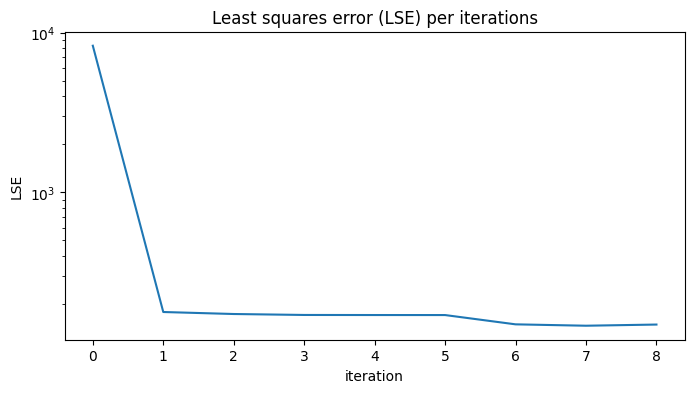

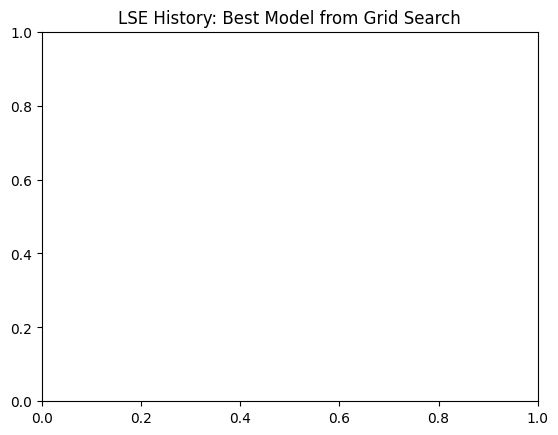

In [53]:
# Plot LSE history
plot_lse(best_model.lse_history)
plt.title("LSE History: Best Model from Grid Search")
plt.show()


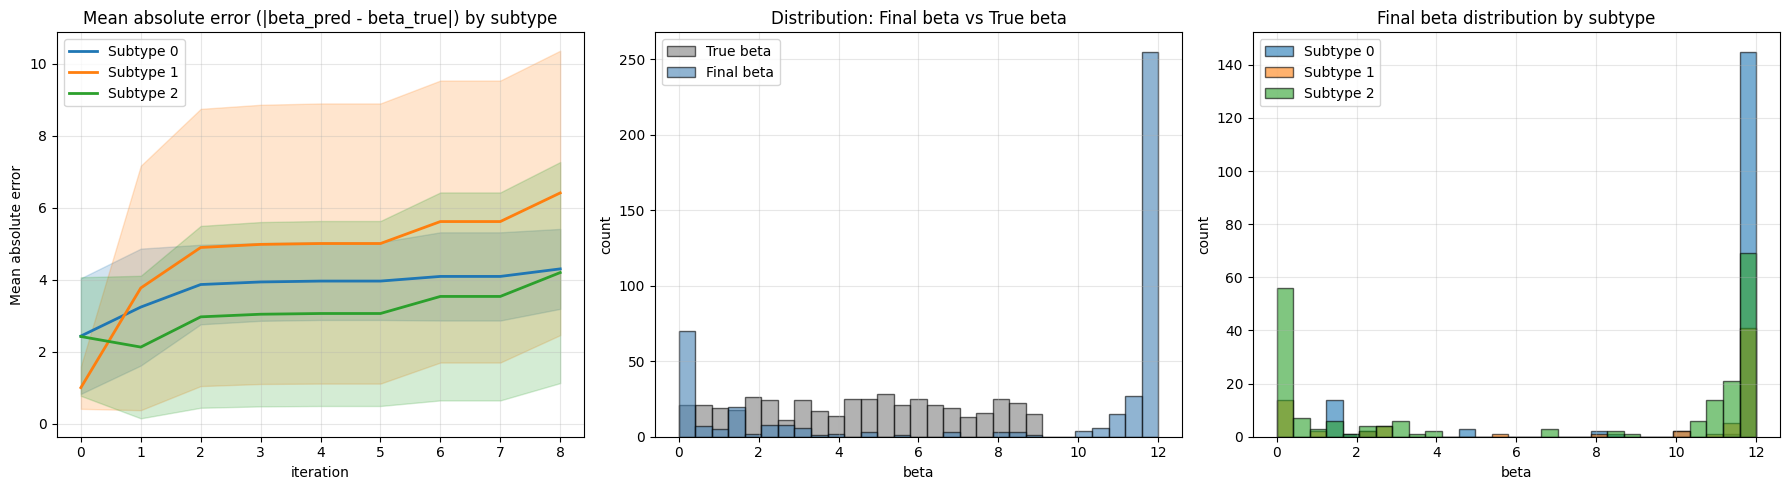

In [54]:
# Plot beta history by subtype
plot_beta_history_by_subtype(
    beta_history=best_model.beta_history,
    assignments=best_model.final_assignments,
    n_subtypes=n_subtypes,
    beta_true=beta_true_array,
    subtype_mapping=subtype_mapping,
)


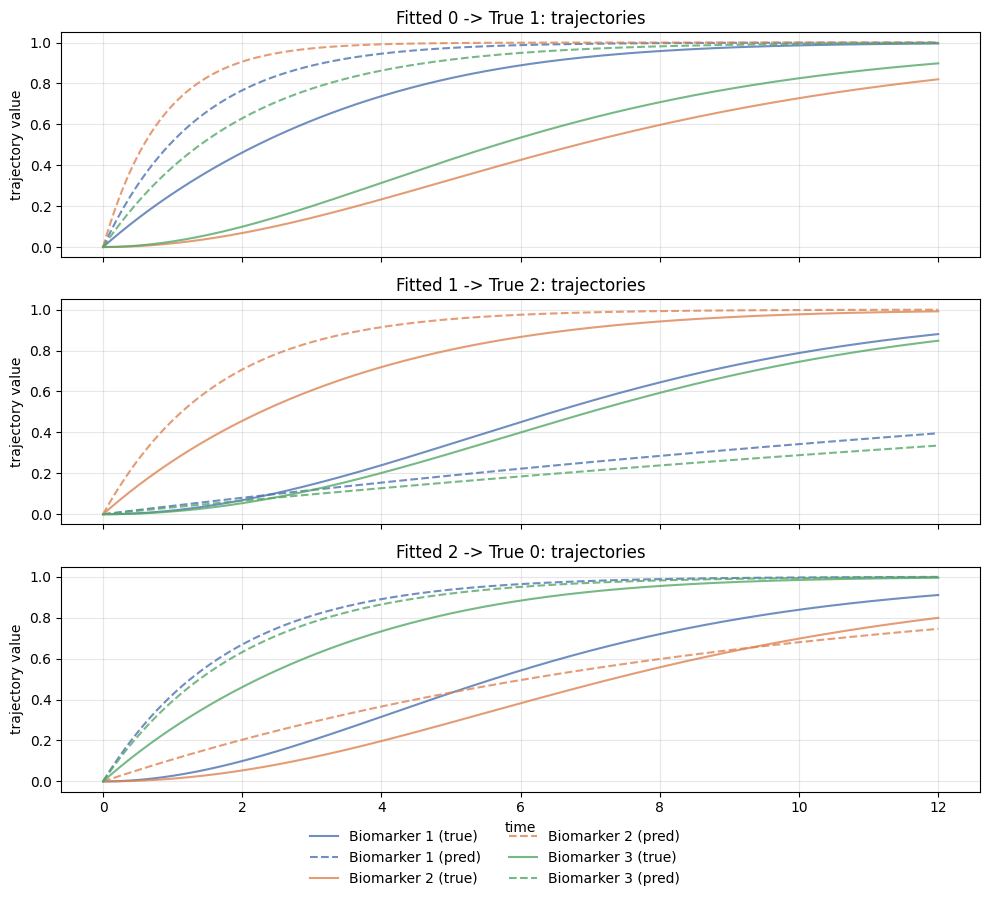

In [55]:
# Plot true vs predicted subtype trajectories
plot_true_vs_predicted_subtype_trajectories(
    n_subtypes=n_subtypes,
    f_true_list=f_list,
    scalar_K_true_list=scalar_K_list,
    f_pred_list=best_model.cluster_f,
    scalar_K_pred_list=[best_model.final_scalar_K] * n_subtypes,
    K=K,
    t_span=t_span,
    n_biomarkers=n_biomarkers,
    solve_system_fn=solve_system,
    subtype_mapping=subtype_mapping,
)


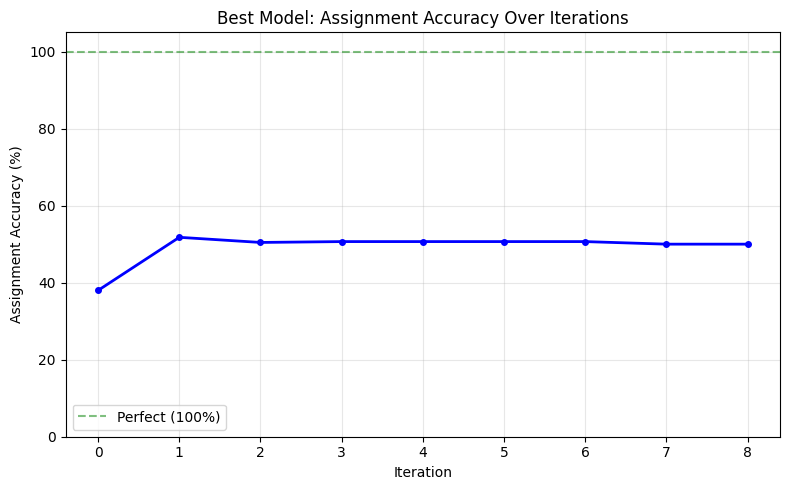

In [56]:
# Plot assignment accuracy over iterations
plot_assignment_accuracy_history(
    assignment_history=best_model.assignment_history,
    true_assignments=assignments_true,
    subtype_mapping=subtype_mapping,
    title="Best Model: Assignment Accuracy Over Iterations",
)


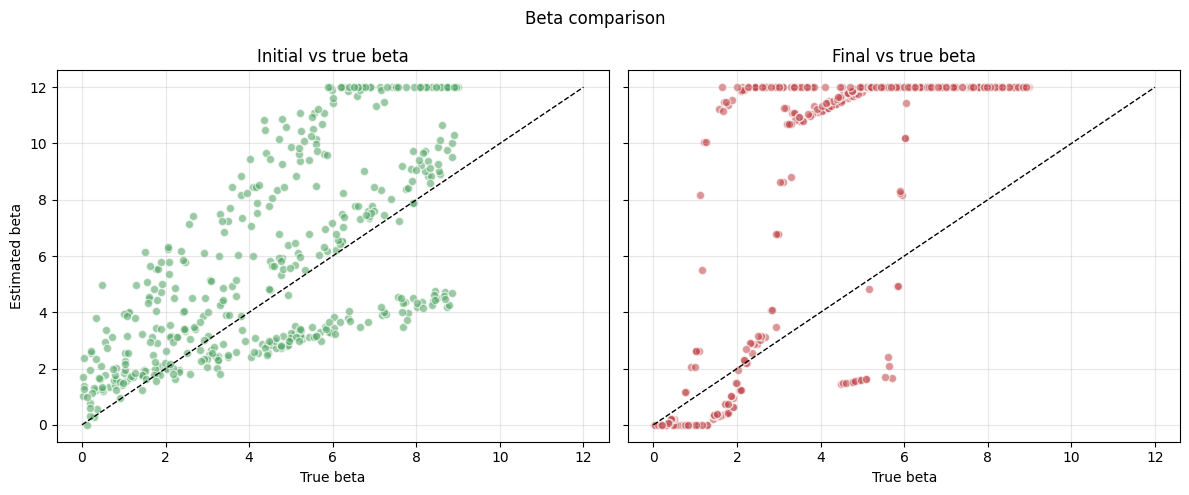

In [57]:
# Plot beta comparison
beta_init_array = np.array([p.get("initial_beta", np.nan) for p in X])
if np.any(np.isnan(beta_init_array)):
    beta_init_array = initial_beta

beta_final_array = best_model.beta_history[:, -1]
plot_beta_comparison(beta_true_array, beta_init_array, beta_final_array)


## Transform on Holdout Set

Create a holdout set and test the transform function on unseen data.

In [58]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Create holdout set (20% of data)
# Note: Ideally this should be done before fitting, but for demonstration we'll do it here
X_trainval, X_holdout = train_test_split(X, test_size=0.2, random_state=75)

# Extract true beta and subtype for holdout set
holdout_ids = [p["id"] for p in X_holdout]
id_to_beta_idx = {pid: idx for idx, pid in enumerate(unique_ids)}
holdout_beta_true = np.array([beta_true_array[id_to_beta_idx[pid]] for pid in holdout_ids])
holdout_subtype_true = np.array([p["subtype_true"] for p in X_holdout])

print(f"Holdout set size: {len(X_holdout)} patients")
print(f"Train/Val set size: {len(X_trainval)} patients")

Holdout set size: 90 patients
Train/Val set size: 360 patients


In [59]:
# Transform on holdout set (with cognitive priors)
transform_results = best_model.transform(X_holdout)

# Extract beta and subtype assignments
holdout_beta_pred = transform_results['beta']
holdout_subtype_pred = transform_results['subtype']

# Map predicted subtypes to true subtypes using the subtype mapping
holdout_subtype_pred_mapped = subtype_mapping[holdout_subtype_pred]

print(f"Beta prediction range: [{np.min(holdout_beta_pred):.2f}, {np.max(holdout_beta_pred):.2f}]")
print(f"Beta true range: [{np.min(holdout_beta_true):.2f}, {np.max(holdout_beta_true):.2f}]")
print(f"\nMean absolute error: {np.mean(np.abs(holdout_beta_pred - holdout_beta_true)):.4f}")
print(f"RMSE: {np.sqrt(np.mean((holdout_beta_pred - holdout_beta_true)**2)):.4f}")

Estimating beta and subtype assignments:   9%|▉         | 8/90 [00:00<00:01, 71.88it/s]

Estimating beta and subtype assignments: 100%|██████████| 90/90 [00:01<00:00, 66.31it/s]

Beta prediction range: [0.00, 12.00]
Beta true range: [0.04, 8.86]

Mean absolute error: 4.1868
RMSE: 4.9774


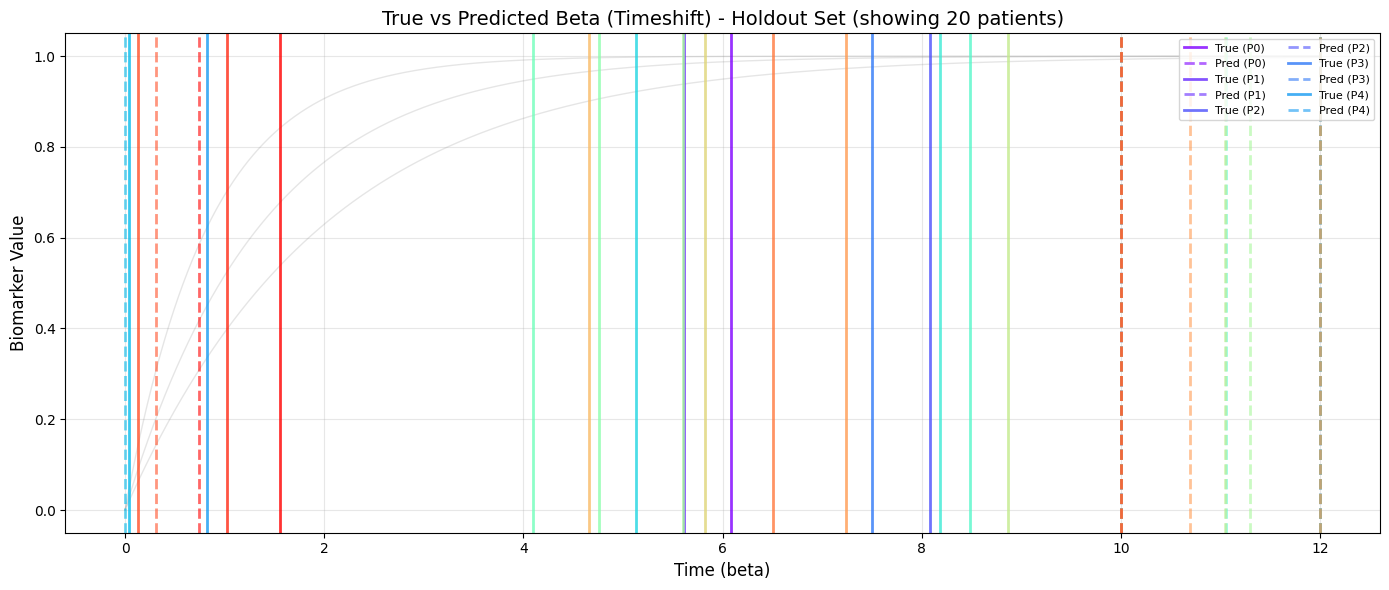

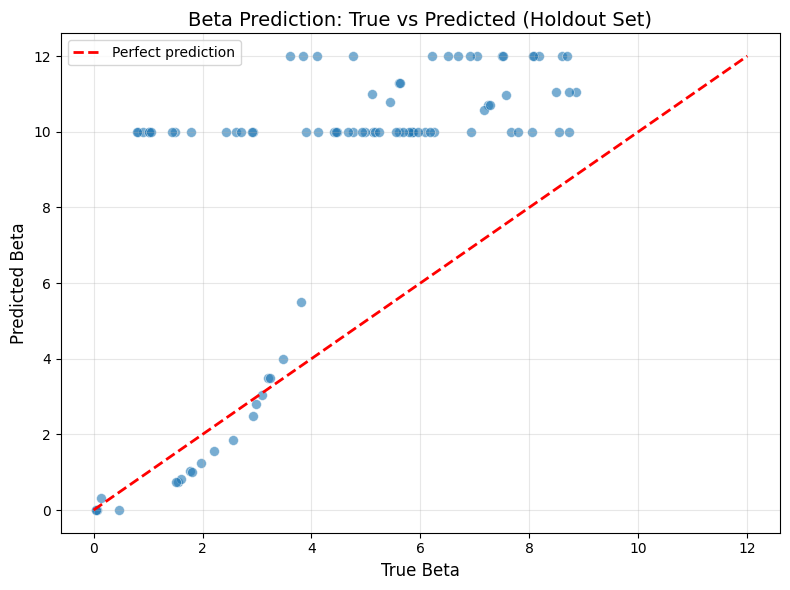

In [60]:
# Plot vertical lines comparing true vs predicted beta
# Get representative trajectory for visualization (use first subtype's trajectory)
f_vis = np.ravel(best_model.cluster_f[0])
scalar_K_vis = best_model.final_scalar_K  # scalar_K is global, not per-subtype
x_vis = solve_system(np.zeros(n_biomarkers), f_vis, K, t_span, scalar_K_vis)

# Sample a subset of patients for visualization (first 20)
n_show = min(20, len(X_holdout))
patient_indices = np.arange(n_show)

fig, ax = plt.subplots(figsize=(14, 6))

# Plot trajectory background
for i in range(n_biomarkers):
    ax.plot(t_span, x_vis[i], color="gray", alpha=0.2, linewidth=1)

# Plot vertical lines for true and predicted beta
colors = plt.cm.rainbow(np.linspace(0, 1, n_show))
for idx, p_idx in enumerate(patient_indices):
    color = colors[idx]
    beta_true_val = holdout_beta_true[p_idx]
    beta_pred_val = holdout_beta_pred[p_idx]
    
    ax.axvline(x=beta_true_val, color=color, linestyle="-", linewidth=2, 
               alpha=0.8, label=f"True (P{p_idx})" if idx < 5 else None)
    ax.axvline(x=beta_pred_val, color=color, linestyle="--", linewidth=2, 
               alpha=0.6, label=f"Pred (P{p_idx})" if idx < 5 else None)

ax.set_xlabel("Time (beta)", fontsize=12)
ax.set_ylabel("Biomarker Value", fontsize=12)
ax.set_title(f"True vs Predicted Beta (Timeshift) - Holdout Set (showing {n_show} patients)", fontsize=14)
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Also create scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(holdout_beta_true, holdout_beta_pred, alpha=0.6, s=50, edgecolors='white', linewidth=0.5)
limits = [min(np.min(holdout_beta_true), np.min(holdout_beta_pred)), 
          max(np.max(holdout_beta_true), np.max(holdout_beta_pred))]
ax.plot(limits, limits, 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel("True Beta", fontsize=12)
ax.set_ylabel("Predicted Beta", fontsize=12)
ax.set_title("Beta Prediction: True vs Predicted (Holdout Set)", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Contingency Matrix: Subtype Assignments (Holdout Set) ===
Rows: True subtypes, Columns: Predicted subtypes (mapped)
[[15 12  4]
 [14 13  8]
 [ 0 13 11]]

Subtype assignment accuracy: 0.4333


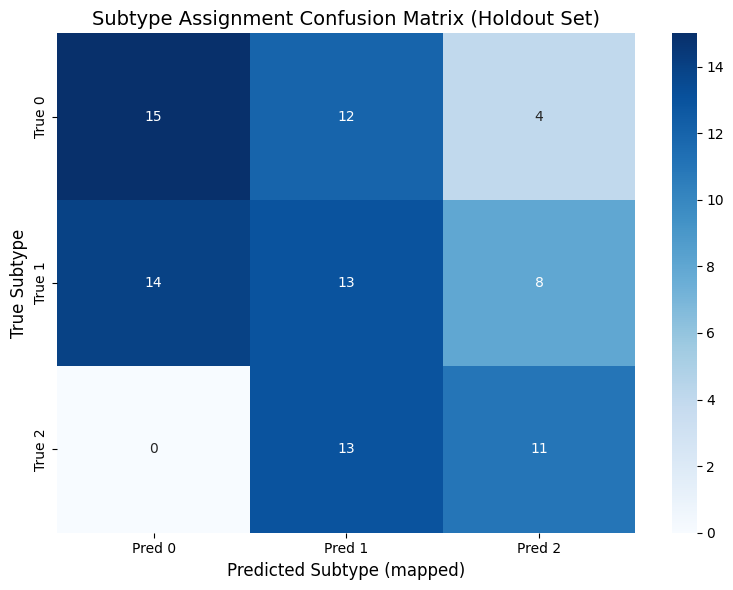

In [61]:
# Contingency matrix (confusion matrix) for subtype assignments
cm_holdout = confusion_matrix(holdout_subtype_true, holdout_subtype_pred_mapped)

print("=== Contingency Matrix: Subtype Assignments (Holdout Set) ===")
print("Rows: True subtypes, Columns: Predicted subtypes (mapped)")
print(cm_holdout)
print()

# Calculate accuracy
accuracy = np.trace(cm_holdout) / np.sum(cm_holdout)
print(f"Subtype assignment accuracy: {accuracy:.4f}")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_holdout, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f"Pred {i}" for i in range(n_subtypes)],
            yticklabels=[f"True {i}" for i in range(n_subtypes)])
plt.title("Subtype Assignment Confusion Matrix (Holdout Set)", fontsize=14)
plt.ylabel("True Subtype", fontsize=12)
plt.xlabel("Predicted Subtype (mapped)", fontsize=12)
plt.tight_layout()
plt.show()

## Transform Without Cognitive Parameters

Test transform on holdout set without cognitive parameters (simulating real-world scenario where cognitive data might not be available).

In [62]:
# Create holdout set without cognitive data (set cog to zeros or remove it)
X_holdout_no_cog = []
for p in X_holdout:
    p_no_cog = p.copy()
    # Set cognitive features to zeros (or you could remove the key entirely)
    # The transform function should handle missing/zero cognitive data
    p_no_cog["cog"] = np.zeros_like(p["cog"])
    X_holdout_no_cog.append(p_no_cog)

# Transform on holdout set without cognitive priors
# Note: The model was trained with lambda_cog=0.0, so cognitive priors weren't used anyway
# But this demonstrates the transform function can work without cognitive data
transform_results_no_cog = best_model.transform(X_holdout_no_cog)

# Extract beta and subtype assignments
holdout_beta_pred_no_cog = transform_results_no_cog['beta']
holdout_subtype_pred_no_cog = transform_results_no_cog['subtype']
holdout_subtype_pred_no_cog_mapped = subtype_mapping[holdout_subtype_pred_no_cog]

print("=== Transform Results WITHOUT Cognitive Parameters ===")
print(f"Beta prediction range: [{np.min(holdout_beta_pred_no_cog):.2f}, {np.max(holdout_beta_pred_no_cog):.2f}]")
print(f"Beta true range: [{np.min(holdout_beta_true):.2f}, {np.max(holdout_beta_true):.2f}]")
print(f"\nMean absolute error: {np.mean(np.abs(holdout_beta_pred_no_cog - holdout_beta_true)):.4f}")
print(f"RMSE: {np.sqrt(np.mean((holdout_beta_pred_no_cog - holdout_beta_true)**2)):.4f}")

# Compare with results WITH cognitive data
print("\n=== Comparison: With vs Without Cognitive Data ===")
print(f"MAE with cog:    {np.mean(np.abs(holdout_beta_pred - holdout_beta_true)):.4f}")
print(f"MAE without cog: {np.mean(np.abs(holdout_beta_pred_no_cog - holdout_beta_true)):.4f}")
print(f"Difference:      {np.mean(np.abs(holdout_beta_pred - holdout_beta_true)) - np.mean(np.abs(holdout_beta_pred_no_cog - holdout_beta_true)):.4f}")

Estimating beta and subtype assignments:   9%|▉         | 8/90 [00:00<00:01, 73.13it/s]

Estimating beta and subtype assignments: 100%|██████████| 90/90 [00:01<00:00, 65.73it/s]

=== Transform Results WITHOUT Cognitive Parameters ===
Beta prediction range: [0.00, 12.00]
Beta true range: [0.04, 8.86]

Mean absolute error: 4.1868
RMSE: 4.9774

=== Comparison: With vs Without Cognitive Data ===
MAE with cog:    4.1868
MAE without cog: 4.1868
Difference:      0.0000


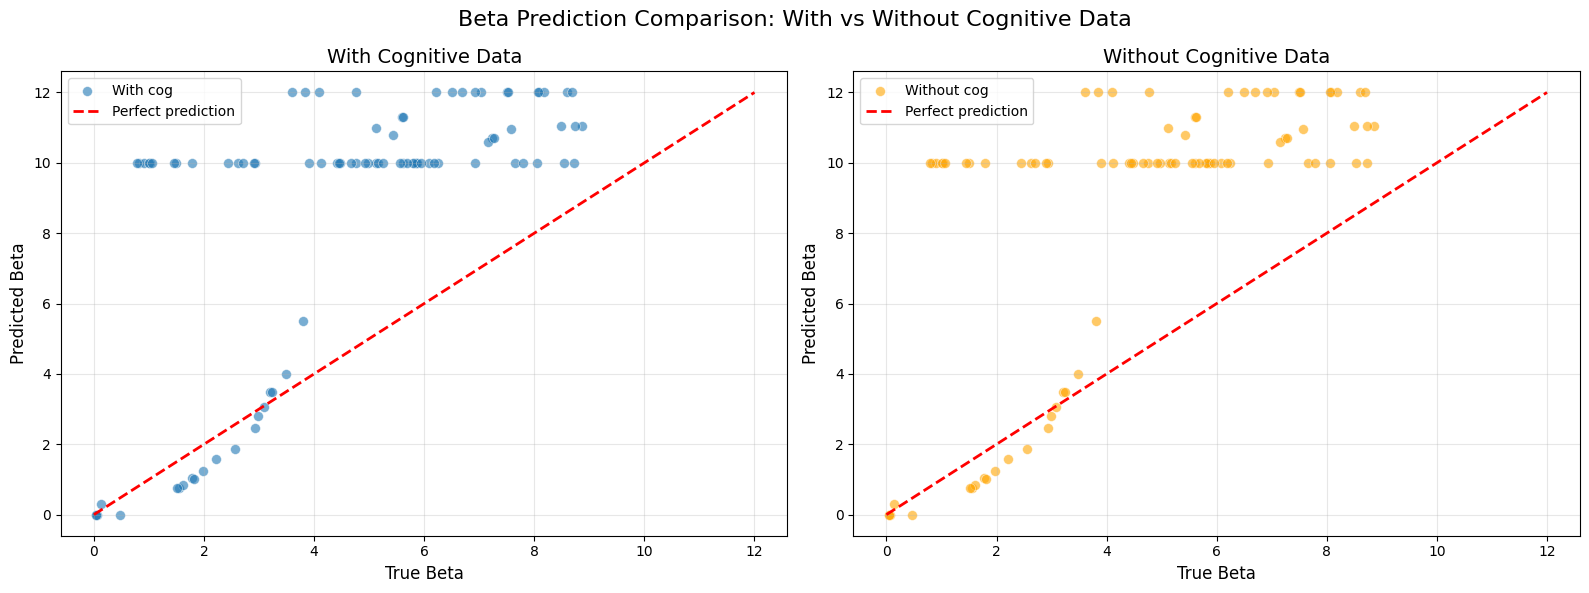


=== Subtype Assignment Comparison ===
Accuracy with cog:    0.4333
Accuracy without cog: 0.4333


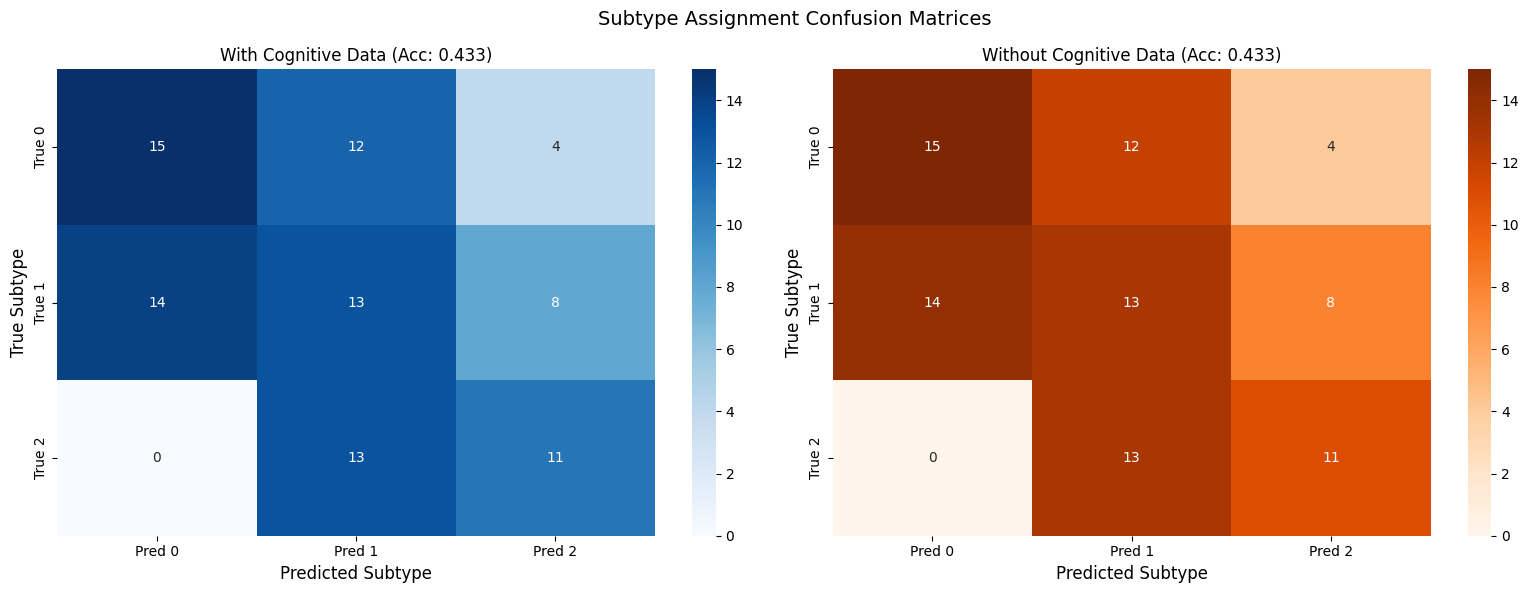

In [63]:
# Plot comparison: with vs without cognitive data
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: With cognitive data
ax = axes[0]
ax.scatter(holdout_beta_true, holdout_beta_pred, alpha=0.6, s=50, edgecolors='white', linewidth=0.5, label='With cog')
limits = [min(np.min(holdout_beta_true), np.min(holdout_beta_pred)), 
          max(np.max(holdout_beta_true), np.max(holdout_beta_pred))]
ax.plot(limits, limits, 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel("True Beta", fontsize=12)
ax.set_ylabel("Predicted Beta", fontsize=12)
ax.set_title("With Cognitive Data", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Right plot: Without cognitive data
ax = axes[1]
ax.scatter(holdout_beta_true, holdout_beta_pred_no_cog, alpha=0.6, s=50, edgecolors='white', linewidth=0.5, 
           color='orange', label='Without cog')
limits = [min(np.min(holdout_beta_true), np.min(holdout_beta_pred_no_cog)), 
          max(np.max(holdout_beta_true), np.max(holdout_beta_pred_no_cog))]
ax.plot(limits, limits, 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel("True Beta", fontsize=12)
ax.set_ylabel("Predicted Beta", fontsize=12)
ax.set_title("Without Cognitive Data", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Beta Prediction Comparison: With vs Without Cognitive Data", fontsize=16)
plt.tight_layout()
plt.show()

# Contingency matrix for subtype assignments without cognitive data
cm_holdout_no_cog = confusion_matrix(holdout_subtype_true, holdout_subtype_pred_no_cog_mapped)
accuracy_no_cog = np.trace(cm_holdout_no_cog) / np.sum(cm_holdout_no_cog)

print("\n=== Subtype Assignment Comparison ===")
print(f"Accuracy with cog:    {accuracy:.4f}")
print(f"Accuracy without cog: {accuracy_no_cog:.4f}")

# Visualize both confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
sns.heatmap(cm_holdout, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=[f"Pred {i}" for i in range(n_subtypes)],
            yticklabels=[f"True {i}" for i in range(n_subtypes)])
ax.set_title(f"With Cognitive Data (Acc: {accuracy:.3f})", fontsize=12)
ax.set_ylabel("True Subtype", fontsize=12)
ax.set_xlabel("Predicted Subtype", fontsize=12)

ax = axes[1]
sns.heatmap(cm_holdout_no_cog, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=[f"Pred {i}" for i in range(n_subtypes)],
            yticklabels=[f"True {i}" for i in range(n_subtypes)])
ax.set_title(f"Without Cognitive Data (Acc: {accuracy_no_cog:.3f})", fontsize=12)
ax.set_ylabel("True Subtype", fontsize=12)
ax.set_xlabel("Predicted Subtype", fontsize=12)

plt.suptitle("Subtype Assignment Confusion Matrices", fontsize=14)
plt.tight_layout()
plt.show()